<a href="https://colab.research.google.com/github/NMH1203/Low-Light-Image-Enhancement-and-Downstream-Recognition/blob/NMH/Notebooks/NMH/exdark_yolo_clahe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
%pip install -q opencv-python-headless tqdm pyyaml

In [5]:
from pathlib import Path
import subprocess

REPO_DIR = Path(
    "/content/Dataset"
)

if not REPO_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth", "1",
            "https://github.com/NMH1203/Low-Light-Image-Enhancement-and-Downstream-Recognition.git",
            str(REPO_DIR),
        ],
        check=True,
    )

print("Repository:", REPO_DIR)

Repository: /content/Dataset


In [6]:
"""CLAHE + bilateral-filter enhancement for the ExDark dataset."""

import cv2
import numpy as np


def enhance_clahe_bilateral(image_bgr: np.ndarray) -> np.ndarray:
    """Increase local luminance contrast, then denoise while preserving edges."""
    if image_bgr is None or image_bgr.size == 0:
        raise ValueError("Input image is empty.")

    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    luminance, channel_a, channel_b = cv2.split(lab)

    luminance = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8),
    ).apply(luminance)

    enhanced = cv2.cvtColor(
        cv2.merge((luminance, channel_a, channel_b)),
        cv2.COLOR_LAB2BGR,
    )

    return cv2.bilateralFilter(
        enhanced,
        d=7,
        sigmaColor=50.0,
        sigmaSpace=50.0,
    )

In [7]:
from pathlib import Path

# Dataset lấy từ GitHub
SOURCE_DATASET = (
    REPO_DIR
    / "Dataset"
    / "exdark_yolo_dark"
)

# Dataset CLAHE mới được lưu thẳng vào Google Drive
OUTPUT_DATASET = Path(
    "/content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe"
)

SPLITS = ["train", "valid", "test"]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}

assert SOURCE_DATASET.exists(), (
    f"Không tìm thấy dataset: {SOURCE_DATASET}"
)

print("Dataset nguồn:", SOURCE_DATASET)
print("Dataset đầu ra:", OUTPUT_DATASET)

Dataset nguồn: /content/Dataset/Dataset/exdark_yolo_dark
Dataset đầu ra: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe


In [8]:
import cv2
import shutil

from tqdm.auto import tqdm

total_processed = 0
total_skipped = 0

for split in SPLITS:
    source_images_dir = SOURCE_DATASET / split / "images"
    source_labels_dir = SOURCE_DATASET / split / "labels"

    output_images_dir = OUTPUT_DATASET / split / "images"
    output_labels_dir = OUTPUT_DATASET / split / "labels"

    output_images_dir.mkdir(parents=True, exist_ok=True)
    output_labels_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(
        path
        for path in source_images_dir.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    label_paths = sorted(source_labels_dir.glob("*.txt"))

    print(
        f"{split}: {len(image_paths)} ảnh, "
        f"{len(label_paths)} labels"
    )

    # Sao chép nguyên nhãn YOLO
    # CLAHE không resize hoặc crop nên bounding box không thay đổi
    for label_path in label_paths:
        shutil.copy2(
            label_path,
            output_labels_dir / label_path.name,
        )

    # Xử lý tuần tự
    for image_path in tqdm(
        image_paths,
        desc=f"CLAHE {split}",
    ):
        # Hiền Anh lưu ảnh tăng cường dưới dạng PNG
        output_path = (
            output_images_dir
            / f"{image_path.stem}.png"
        )

        # Cho phép tiếp tục nếu Colab bị ngắt giữa chừng
        if output_path.exists() and output_path.stat().st_size > 0:
            total_skipped += 1
            continue

        image_bgr = cv2.imread(
            str(image_path),
            cv2.IMREAD_COLOR,
        )

        if image_bgr is None:
            raise ValueError(
                f"Không đọc được ảnh: {image_path}"
            )

        original_shape = image_bgr.shape

        enhanced_bgr = enhance_clahe_bilateral(image_bgr)

        if enhanced_bgr.shape != original_shape:
            raise ValueError(
                f"Kích thước ảnh bị thay đổi: {image_path}"
            )

        success = cv2.imwrite(
            str(output_path),
            enhanced_bgr,
            [cv2.IMWRITE_PNG_COMPRESSION, 3],
        )

        if not success:
            raise IOError(
                f"Không lưu được ảnh: {output_path}"
            )

        total_processed += 1

print("\nHoàn thành xử lý CLAHE")
print("Ảnh mới xử lý:", total_processed)
print("Ảnh đã tồn tại:", total_skipped)

train: 5142 ảnh, 5142 labels


CLAHE train:   0%|          | 0/5142 [00:00<?, ?it/s]

valid: 1469 ảnh, 1469 labels


CLAHE valid:   0%|          | 0/1469 [00:00<?, ?it/s]

test: 734 ảnh, 734 labels


CLAHE test:   0%|          | 0/734 [00:00<?, ?it/s]


Hoàn thành xử lý CLAHE
Ảnh mới xử lý: 7345
Ảnh đã tồn tại: 0


In [9]:
import yaml

source_yaml = SOURCE_DATASET / "data.yaml"
output_yaml = OUTPUT_DATASET / "data.yaml"

with open(source_yaml, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["path"] = OUTPUT_DATASET.as_posix()
config["train"] = "train/images"
config["val"] = "valid/images"
config["test"] = "test/images"

if "names" in config:
    config["nc"] = len(config["names"])

with open(output_yaml, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Đã tạo:", output_yaml)
print("\nNội dung data.yaml:")
print(output_yaml.read_text(encoding="utf-8"))

Đã tạo: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe/data.yaml

Nội dung data.yaml:
path: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe
train: train/images
val: valid/images
test: test/images
names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Cat
  5: Cup
  6: Motorbike
  7: People
  8: Table
  9: car
  10: chair
  11: dog
nc: 12



In [10]:
for split in SPLITS:
    image_count = len(
        list(
            (
                OUTPUT_DATASET
                / split
                / "images"
            ).glob("*.png")
        )
    )

    label_count = len(
        list(
            (
                OUTPUT_DATASET
                / split
                / "labels"
            ).glob("*.txt")
        )
    )

    status = "OK" if image_count == label_count else "LỖI"

    print(
        f"{split:5s}: "
        f"{image_count} ảnh, "
        f"{label_count} labels — {status}"
    )

    assert image_count == label_count

train: 5142 ảnh, 5142 labels — OK
valid: 1469 ảnh, 1469 labels — OK
test : 734 ảnh, 734 labels — OK


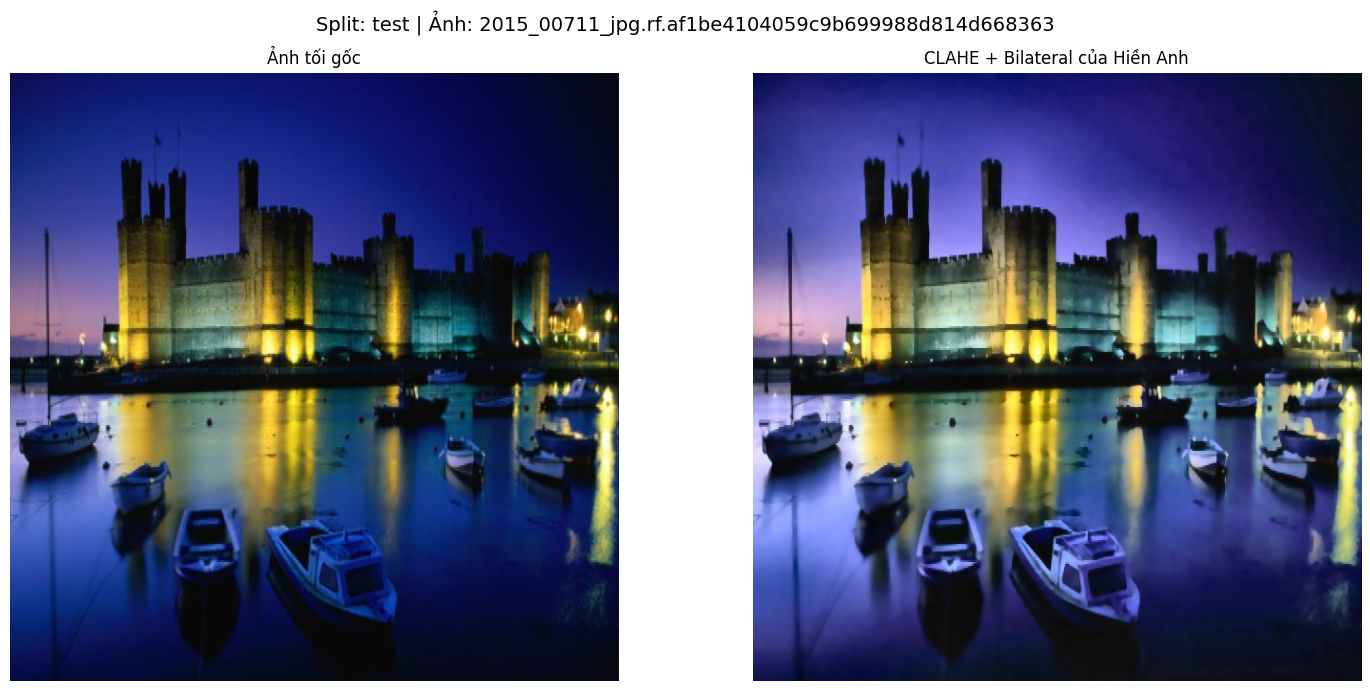

Ảnh gốc: /content/Dataset/Dataset/exdark_yolo_dark/test/images/2015_00711_jpg.rf.af1be4104059c9b699988d814d668363.jpg
Ảnh CLAHE: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe/test/images/2015_00711_jpg.rf.af1be4104059c9b699988d814d668363.png


In [11]:
import random
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

DARK_DATASET = (
    REPO_DIR
    / "Dataset"
    / "exdark_yolo_dark"
)

CLAHE_DATASET = Path(
    "/content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp", ".tif", ".tiff",
}

# Chọn ngẫu nhiên split
split = random.choice([
    "train",
    "valid",
    "test",
])

clahe_image_dir = (
    CLAHE_DATASET
    / split
    / "images"
)

clahe_images = [
    path
    for path in clahe_image_dir.iterdir()
    if (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )
]

if not clahe_images:
    raise FileNotFoundError(
        f"Không tìm thấy ảnh CLAHE trong {clahe_image_dir}"
    )

# Chọn ngẫu nhiên một ảnh CLAHE
clahe_path = random.choice(clahe_images)

# Tìm ảnh gốc có cùng stem
dark_image_dir = (
    DARK_DATASET
    / split
    / "images"
)

dark_candidates = [
    path
    for path in dark_image_dir.iterdir()
    if (
        path.is_file()
        and path.stem == clahe_path.stem
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )
]

if not dark_candidates:
    raise FileNotFoundError(
        f"Không tìm được ảnh gốc của {clahe_path.name}"
    )

dark_path = dark_candidates[0]

# Đọc ảnh
dark_bgr = cv2.imread(str(dark_path))
clahe_bgr = cv2.imread(str(clahe_path))

if dark_bgr is None:
    raise ValueError(f"Không đọc được ảnh gốc: {dark_path}")

if clahe_bgr is None:
    raise ValueError(f"Không đọc được ảnh CLAHE: {clahe_path}")

# OpenCV đọc BGR, matplotlib cần RGB
dark_rgb = cv2.cvtColor(
    dark_bgr,
    cv2.COLOR_BGR2RGB,
)

clahe_rgb = cv2.cvtColor(
    clahe_bgr,
    cv2.COLOR_BGR2RGB,
)

# Hiển thị
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(dark_rgb)
plt.title("Ảnh tối gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_rgb)
plt.title("CLAHE + Bilateral của Hiền Anh")
plt.axis("off")

plt.suptitle(
    f"Split: {split} | Ảnh: {clahe_path.stem}",
    fontsize=14,
)

plt.tight_layout()
plt.show()

print("Ảnh gốc:", dark_path)
print("Ảnh CLAHE:", clahe_path)